### Claims example - 2D simplified data
In our example, we have a target `Handling`, being either `Accepted` or `Rejected`, (1 or 0, respectively).

The simplified data has 2 features:
- `within_30_days`: Whether or not (1 or 0) the claim was made within 30 days of the purchase date.
- `defect_visible_in_attachment`: Whether or not (1 or 0) the defect was visible in the attached image of the piece of clothing.

Additionally, it has a `claim_number` column, which is not relevant for the model, but simply to identify it in the cloud storage.

To load this data, we will use the `pandas` library. The data is stored in a CSV file, which we will read into a DataFrame. We will then convert the DataFrame to a NumPy array for processing.

In [6]:
import sys
import os

# Ensure import from parent directory works
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../')))

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


from py_perceptron import PyPerceptron


In [8]:
claims_data = pd.read_csv("../../data/claims_example_2d.csv", sep=";")
print(claims_data)

  claim_number  within_30_days  defect_visible_in_attachment  handling
0  PCLM0070028               1                             1         1
1  PCLM0070027               1                             1         1
2  PCLM0070026               1                             1         1
3  PCLM0070025               0                             1         1
4  PCLM0076843               0                             0         0
5  PCLM0075964               1                             0         0
6  PCLM0075598               1                             0         0


In [9]:
def plot_decision_boundary_claims_2d(weights, X, y, plot_title="Perceptron decision boundary", X_label="X1", y_label="X2", decision_boundary_label="Decision boundary"):
    w0, w1, w2 = weights

    # Formula (with only 2D data): w0 + w1*x1 + w2*x2 = 0
    # Rearranging gives: x2 = -(w0/w2) - (w1/w2)*x1
    x1_values = np.linspace(-2.5, 2.5, 100) # Create a list of x1 values
    x2_values = -(w0 / w2) - (w1 / w2) * x1_values

    # Formula:
    # print(f"Decision Boundary: x2 = {-(w0 / w2)} - ({w1 / w2}) * x1")
    # print(f"Decision Boundary: 0 = {w0} + {w1} * x1 + {w2} * x2")

    # Plot data points
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Rejected') # Select all rows where y == 0 (all Rejected claims)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Accepted') # Select all rows where y == 1 (all Accepted claims)

    # Plot decision boundary
    plt.plot(x1_values, x2_values, color='green', label=decision_boundary_label, linewidth=2)

    # Axis labels and legend
    plt.xlabel(X_label)
    plt.ylabel(y_label)
    plt.title(plot_title)
    plt.legend()
    plt.grid(True)
    plt.show()

X_claims:  [[1 1]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [1 0]
 [1 0]]
Target:  [1 1 1 1 0 0 0]


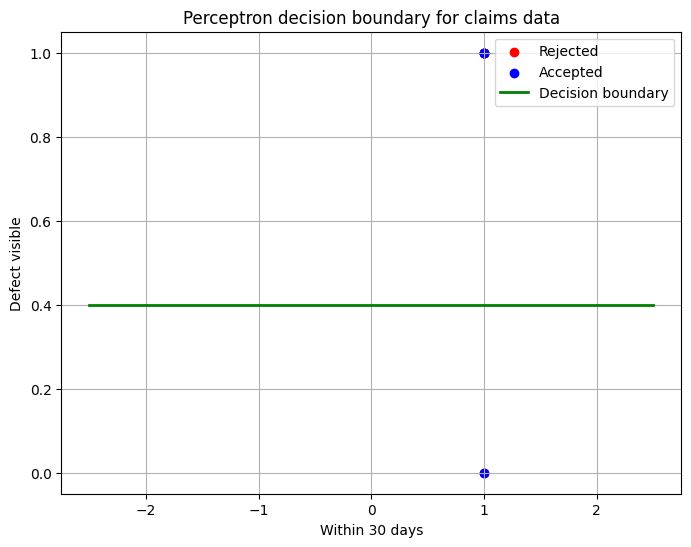

[[4 0]
 [0 3]]


<Figure size 800x600 with 0 Axes>

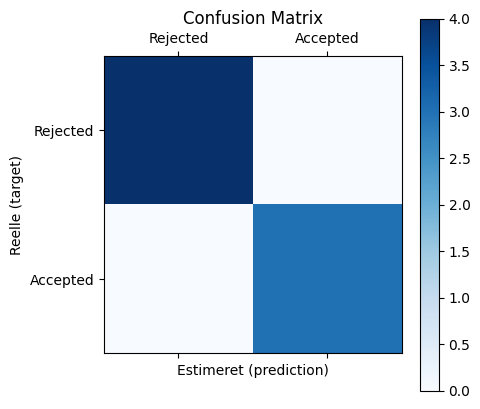

array([[3, 0],
       [0, 4]])

In [10]:
def heaviside_step(x):
    # Heaviside step function
    return 1 if x >= 0 else 0

VERBOSE = False # Toggle to True for model output

# Remove claim_number (not relevant for training), and set handling as target
training_data = claims_data.drop(columns=["claim_number"])
target_labels = training_data.pop("handling") # Extract the target labels

# Convert to numpy arrays
X_claims = np.array(training_data)
y_claims = np.array(target_labels)
print("X_claims: ", X_claims)
print("Target: ", y_claims)

# Initialize the perceptron with 2 input features
p = PyPerceptron(learning_rate=0.1, n_epochs=1000, activation_function=heaviside_step, init_weight_value=0.5, verbose=VERBOSE)

X_claims_data = p.fit(X_claims)
p.train(X_claims_data, y_claims)

plot_decision_boundary_claims_2d(p.weights, X_claims_data, y_claims, plot_title="Perceptron decision boundary for claims data", X_label="Within 30 days", y_label="Defect visible", decision_boundary_label="Decision boundary")


print(p.confusion_matrix(y_claims, p.predict(X_claims_data)))

plt.figure(figsize=(8, 6))
plt.matshow(p.confusion_matrix(y_claims, p.predict(X_claims_data)), cmap='Blues', interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Estimeret (prediction)")
plt.ylabel("Reelle (target)")
plt.xticks([0, 1], ["Rejected", "Accepted"])
plt.yticks([0, 1], ["Rejected", "Accepted"])
plt.show()
confusion_matrix(y_claims, p.predict(X_claims_data), labels=[0, 1])